# Кейс для продуктового аналитика к стажировке в Т-Банк

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_excel("product_case.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Дата              57 non-null     object
 1   Неделя            57 non-null     object
 2   Установки         57 non-null     int64 
 3   Регистрации       57 non-null     int64 
 4   Открыли поиск     57 non-null     int64 
 5   Просмотрели авто  57 non-null     int64 
 6   Забронировали     57 non-null     int64 
 7   Первая поездка    57 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 3.7+ KB


In [4]:
print('Исходные названия в столбце недель:', df["Неделя"].unique())
df_without_total = df.loc[:55, :]
print('Без последней строки: ', df_without_total["Неделя"].unique())

Исходные названия в столбце недель: ['Неделя 1' 'Неделя 2' 'Неделя 3' 'Неделя 4' 'Неделя 5' 'Неделя 6'
 'Неделя 7' 'Неделя 8' 'Нед. 1–8']
Без последней строки:  ['Неделя 1' 'Неделя 2' 'Неделя 3' 'Неделя 4' 'Неделя 5' 'Неделя 6'
 'Неделя 7' 'Неделя 8']


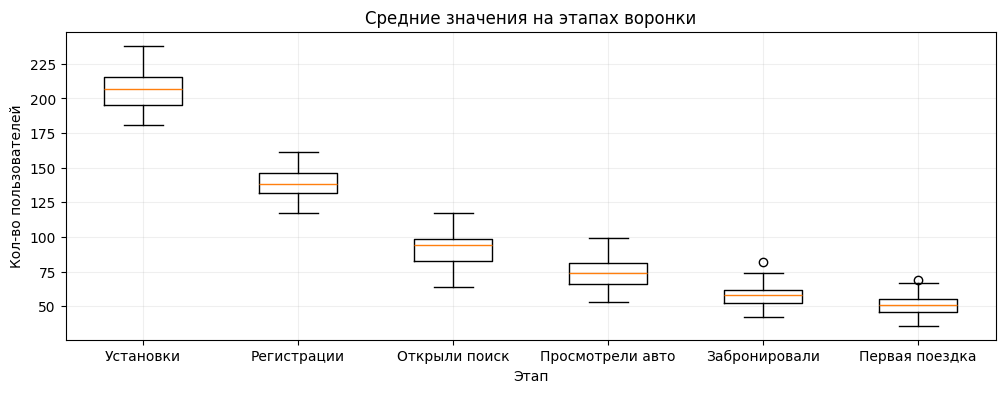

In [5]:
funnel = ["Установки", "Регистрации", "Открыли поиск", "Просмотрели авто", "Забронировали", "Первая поездка"]
data = [df_without_total[f] for f in funnel]

plt.figure(figsize=(12, 4))
plt.boxplot(data)
plt.grid(True, alpha=0.2)
plt.title("Средние значения на этапах воронки")
plt.xlabel("Этап")
plt.ylabel("Кол-во пользователей")
plt.xticks(ticks=list(range(1, len(funnel) + 1)), labels=funnel)

plt.show()

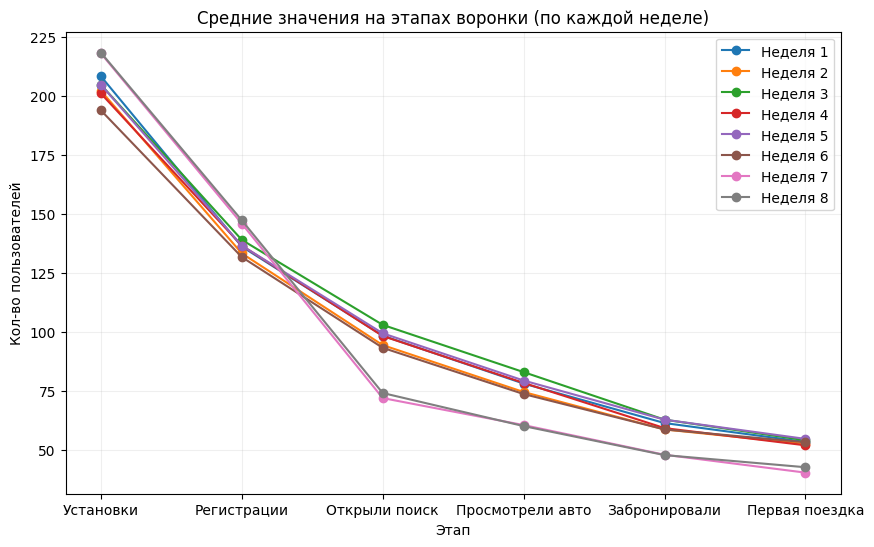

In [6]:
funnel = ["Установки", "Регистрации", "Открыли поиск", "Просмотрели авто", "Забронировали", "Первая поездка"]

plt.figure(figsize=(10, 6))
for week in df_without_total["Неделя"].unique():
  week_means = df_without_total[df_without_total["Неделя"] == week].loc[:, funnel].mean()
  plt.plot(funnel, week_means, marker='o', label=week)
plt.title("Средние значения на этапах воронки (по каждой неделе)")
plt.xlabel("Этап")
plt.ylabel("Кол-во пользователей")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

In [7]:
print('Отклонения от указанных на графике средних')
for week in df_without_total["Неделя"].unique():
  week_stds = df_without_total[df_without_total["Неделя"] == week].loc[:, funnel].std()
  print(week, week_stds.values)

Отклонения от указанных на графике средних
Неделя 1 [12.60574321 10.28637564  8.26351707  8.98941176  7.56873267  5.88379534]
Неделя 2 [12.75968353 11.22072912  9.71008312  9.21696159  9.69044694  8.73416935]
Неделя 3 [12.77646646 10.          6.95221787  7.02376917  5.78586126  5.52052447]
Неделя 4 [14.52583905 10.24462693  5.79408565  5.15936504  3.86066858  3.21455025]
Неделя 5 [12.16161017 10.19570404  9.96422171  9.81252843  9.24533344  6.60086574]
Неделя 6 [6.46602844 6.52467843 2.28868854 4.11154009 3.35232684 3.30223589]
Неделя 7 [14.07124728  9.38844274  6.08276253  5.79819348  4.50924975  3.59894164]
Неделя 8 [15.66007967  9.86093785  5.4902511   4.05908739  4.09994193  3.25137334]


In [23]:
first_week = df_without_total[df_without_total["Неделя"] == "Неделя 1"].loc[:, funnel].mean()
last_week = df_without_total[df_without_total["Неделя"] == "Неделя 8"].loc[:, funnel].mean()
print("Средние по неделе значения изменились на ... % с 1й по 8ю недели:")
print(100 * (last_week - first_week) / first_week)

Средние по неделе значения изменились на ... % с 1й по 8ю недели:
Установки            4.801097
Регистрации          8.184680
Открыли поиск      -24.673440
Просмотрели авто   -23.034735
Забронировали      -22.093023
Первая поездка     -20.053476
dtype: float64


In [43]:
df_without_total[df_without_total["Неделя"] == "Неделя 1"].loc[:, funnel[i]].mean()

np.float64(53.42857142857143)

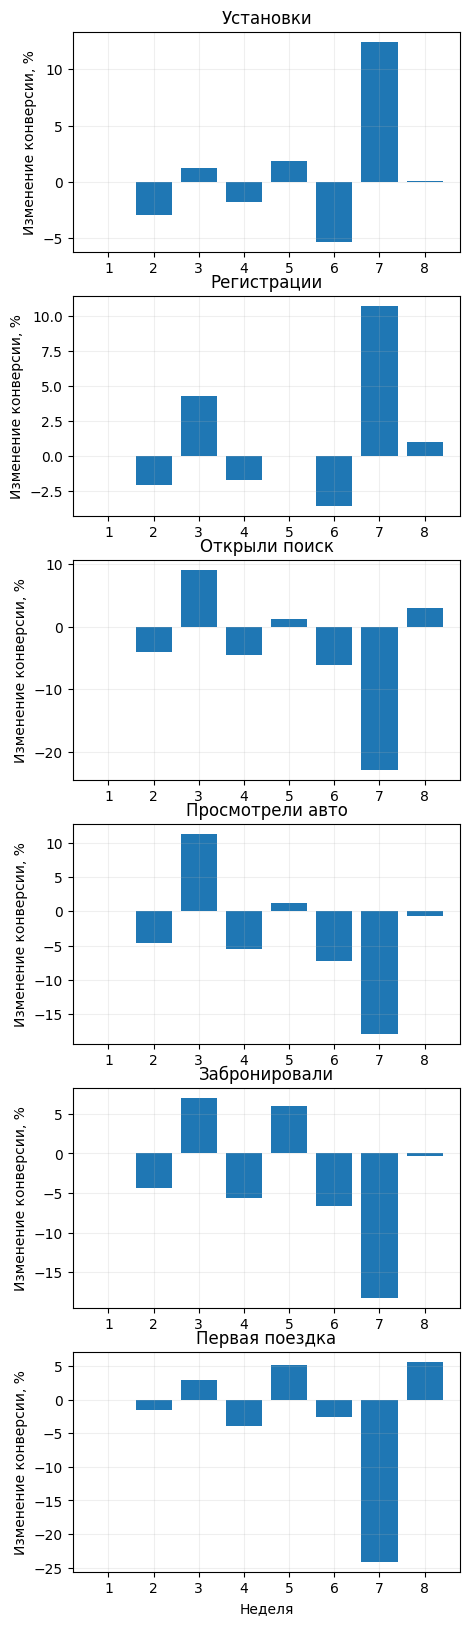

In [44]:
fig, axs = plt.subplots(len(funnel), 1, figsize=(5, 20))
#plt.title("Изменение среднего числа пользователей за неделю")
weeks = df_without_total["Неделя"].unique()
for i in range(len(funnel)):
  data = []
  prev_week = 0
  for w in range(len(weeks)):
    new_week = df_without_total[df_without_total["Неделя"] == weeks[w]].loc[:, funnel[i]].mean()
    if prev_week == 0:
      data.append(0)
    else:
      data.append(100*(new_week - prev_week) / prev_week)
    prev_week = new_week
  axs[i].bar(list(range(len(weeks))), data)
  axs[i].set_title(funnel[i])
  axs[i].set_ylabel("Изменение конверсии, %")
  axs[i].set_xticks(list(range(len(weeks))))
  axs[i].set_xticklabels(list(range(1, len(weeks) + 1)))
  axs[i].grid(True, alpha=0.2)
axs[-1].set_xlabel("Неделя")
plt.show()